In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.model_selection import ParameterGrid

In [63]:
circle_df = pd.read_csv('dataset.csv')
slider_df = pd.read_csv('dataset_slider.csv')
# Merge the columns of the two dataframes, but keep out the BeatmapID column.
id_df = pd.merge(circle_df, slider_df, on=['BeatmapID'], how='left')
# Print the columns of id_df
print(id_df.columns)
# Remove the beatmap ID column
df = id_df.drop(['BeatmapID'], axis=1)

Index(['BeatmapID', 'Angle_0', 'Angle_1', 'Angle_2', 'Angle_3', 'Time_0',
       'Time_1', 'Time_2', 'Time_3', 'Distance_0', 'Distance_1', 'Distance_2',
       'Distance_3', 'SRatio', 'SLength_0', 'SLength_1', 'SLength_2',
       'SLength_3', 'SVelocity_0', 'SVelocity_1', 'SVelocity_2',
       'SVelocity_3'],
      dtype='object')


In [64]:
pca_2 = PCA(n_components=2)
pca_2_result = pca_2.fit_transform(df)
print('Explained variation per principal component: {}'.format(pca_2.explained_variance_ratio_))
print('Cumulative variance explained by 2 principal components: {:.2%}'.format(np.sum(pca_2.explained_variance_ratio_)))

# Results from pca.components_
dataset_pca = pd.DataFrame(abs(pca_2.components_), columns=df.columns, index=['PC_1', 'PC_2'])
print('\n\n', dataset_pca)

print("\n*************** Most important features *************************")
print('As per PC 1:\n', (dataset_pca[dataset_pca > 0.3].iloc[0]).dropna())
print('\n\nAs per PC 2:\n', (dataset_pca[dataset_pca > 0.3].iloc[1]).dropna())
print("\n******************************************************************")

Explained variation per principal component: [0.28912224 0.168683  ]
Cumulative variance explained by 2 principal components: 45.78%


        Angle_0   Angle_1   Angle_2   Angle_3    Time_0    Time_1    Time_2  \
PC_1  0.070957  0.224803  0.239857  0.055904  0.286710  0.423352  0.015943   
PC_2  0.034475  0.336443  0.078658  0.292260  0.235001  0.072138  0.003358   

        Time_3  Distance_0  Distance_1  ...  Distance_3    SRatio  SLength_0  \
PC_1  0.694118    0.041649    0.155589  ...    0.096962  0.048271   0.101932   
PC_2  0.159505    0.036633    0.260803  ...    0.563332  0.130703   0.258167   

      SLength_1  SLength_2  SLength_3  SVelocity_0  SVelocity_1  SVelocity_2  \
PC_1   0.014172   0.068487   0.022324     0.000605     0.010503     0.013053   
PC_2   0.142915   0.378795   0.028682     0.003568     0.039247     0.026454   

      SVelocity_3  
PC_1     0.000102  
PC_2     0.002830  

[2 rows x 21 columns]

*************** Most important features ***********************

Parameter: {'n_clusters': 3} Score 0.17468392231385627
Parameter: {'n_clusters': 7} Score 0.1398471106045126
Parameter: {'n_clusters': 15} Score 0.14226229004853239
Parameter: {'n_clusters': 38} Score 0.11418167152990345
Parameter: {'n_clusters': 77} Score 0.10372605700463272
Parameter: {'n_clusters': 155} Score 0.08997948823196371
Parameter: {'n_clusters': 775} Score 0.0768228213239823
Parameter: {'n_clusters': 1551} Score 0.0755694634499048
Parameter: {'n_clusters': 3102} Score 0.07538491570536696
Parameter: {'n_clusters': 7755} Score 0.07944960625895633
Parameter: {'n_clusters': 15511} Score 0.08112015212364349


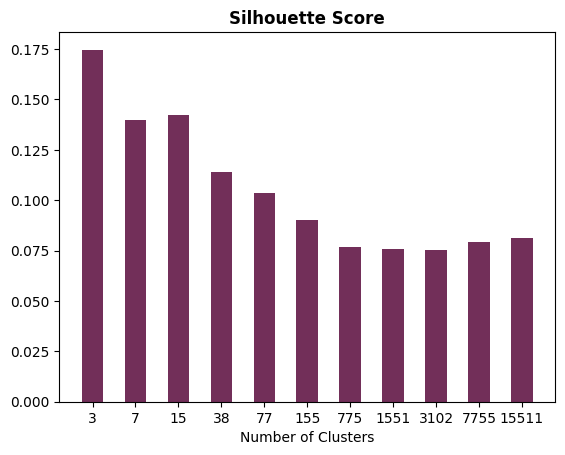

In [65]:
parameters = [3, 7, 15, 38, 77, 155, 775, 1551, 3102, 7755, 15511]

# instantiating ParameterGrid, pass number of clusters as input
parameter_grid = ParameterGrid({'n_clusters': parameters})

best_score = -1
kmeans_model = KMeans(init='k-means++', n_init='auto', random_state=42)
silhouette_scores = []

# evaluation based on silhouette_score
for p in parameter_grid:
    kmeans_model.set_params(**p)    # set current hyper parameter
    kmeans_model.fit(df)          # fit model on wine dataset, this will find clusters based on parameter p

    ss = metrics.silhouette_score(df, kmeans_model.labels_)   # calculate silhouette_score
    silhouette_scores += [ss]       # store all the scores

    print('Parameter:', p, 'Score', ss)

    # check p which has the best score
    if ss > best_score:
        best_score = ss
        best_grid = p

# plotting silhouette score
plt.bar(range(len(silhouette_scores)), list(silhouette_scores), align='center', color='#722f59', width=0.5)
plt.xticks(range(len(silhouette_scores)), list(parameters))
plt.title('Silhouette Score', fontweight='bold')
plt.xlabel('Number of Clusters')
plt.show()

In [66]:
kmeans = KMeans(init='k-means++', n_clusters=15511, n_init='auto', random_state=42)
kmeans.fit(df)
centroids = kmeans.cluster_centers_
centroids_pca = pca_2.transform(centroids)

c:\Users\ozone\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


In [90]:
# Find the row in the df with beatmapID = 3018109
beatmapID = 2665294
beatmap_row = id_df.loc[id_df['BeatmapID'] == beatmapID]

# Find the cluster that the beatmap belongs to
beatmap_cluster = kmeans.predict(beatmap_row.drop(['BeatmapID'], axis=1))
print(beatmap_cluster)

# Find rows in df that belong to the same cluster
cluster_rows = id_df.loc[kmeans.labels_ == beatmap_cluster[0]]
# Create a list of BeatmapIDs in the same cluster
cluster_beatmaps = cluster_rows['BeatmapID'].tolist()
print(cluster_beatmaps)

[11304]
[1649243, 1829478, 1830635, 2030834, 2207263, 2306846, 2665294, 3536969, 3675450, 3802334, 536534]
